In [1]:
import os

dataset_path = "archive/lfw-deepfunneled/lfw-deepfunneled"

people = []
image_count = {}

for person in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person)
    
    if os.path.isdir(person_path):
        images = os.listdir(person_path)
        
        if len(images) >= 20:
            people.append(person)
            image_count[person] = len(images)

print("People selected:", len(people))

for name, count in image_count.items():
    print(name, count)

People selected: 62
Alejandro_Toledo 39
Alvaro_Uribe 35
Amelie_Mauresmo 21
Andre_Agassi 36
Angelina_Jolie 20
Ariel_Sharon 77
Arnold_Schwarzenegger 42
Atal_Bihari_Vajpayee 24
Bill_Clinton 29
Carlos_Menem 21
Colin_Powell 236
David_Beckham 31
Donald_Rumsfeld 121
George_Robertson 22
George_W_Bush 530
Gerhard_Schroeder 109
Gloria_Macapagal_Arroyo 44
Gray_Davis 26
Guillermo_Coria 30
Hamid_Karzai 22
Hans_Blix 39
Hugo_Chavez 71
Igor_Ivanov 20
Jack_Straw 28
Jacques_Chirac 52
Jean_Chretien 55
Jennifer_Aniston 21
Jennifer_Capriati 42
Jennifer_Lopez 21
Jeremy_Greenstock 24
Jiang_Zemin 20
John_Ashcroft 53
John_Negroponte 31
Jose_Maria_Aznar 23
Juan_Carlos_Ferrero 28
Junichiro_Koizumi 60
Kofi_Annan 32
Laura_Bush 41
Lindsay_Davenport 22
Lleyton_Hewitt 41
Luiz_Inacio_Lula_da_Silva 48
Mahmoud_Abbas 29
Megawati_Sukarnoputri 33
Michael_Bloomberg 20
Naomi_Watts 22
Nestor_Kirchner 37
Paul_Bremer 20
Pete_Sampras 22
Recep_Tayyip_Erdogan 30
Ricardo_Lagos 27
Roh_Moo-hyun 32
Rudolph_Giuliani 26
Saddam_Hussein 2

In [2]:
import cv2
import numpy as np

IMAGE_SIZE = 96

images = []
labels = []
label_map = {}

label_id = 0

for person in os.listdir(dataset_path):

    person_path = os.path.join(dataset_path, person)

    if os.path.isdir(person_path) and len(os.listdir(person_path)) >= 20:

        label_map[label_id] = person

        for img_name in os.listdir(person_path):

            img_path = os.path.join(person_path, img_name)

            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
            img = img / 255.0

            images.append(img)
            labels.append(label_id)

        label_id += 1

images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: (3023, 96, 96, 3)
Labels shape: (3023,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42
)

In [4]:
import tensorflow as tf

num_classes = len(label_map)

model = tf.keras.Sequential([
    
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(96,96,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\soham\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 94, 94, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 47, 47, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 20, 20, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 10, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       3,277,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 62)                  │          15,934 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,386,238 (12.92 MB)

 Trainable params: 3,386,238 (12.92 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.1758 - loss: 3.6399 - val_accuracy: 0.2231 - val_loss: 3.3207
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.3387 - loss: 2.7422 - val_accuracy: 0.3719 - val_loss: 2.5282
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.5835 - loss: 1.5685 - val_accuracy: 0.4430 - val_loss: 2.1746
Epoch 4/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.7891 - loss: 0.7581 - val_accuracy: 0.5207 - val_loss: 2.0153
Epoch 5/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9222 - loss: 0.2741 - val_accuracy: 0.5438 - val_loss: 2.1041
Epoch 6/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9690 - loss: 0.1097 - val_accuracy: 0.5521 - val_loss: 2.4061
Epoch 7/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9909 - loss: 0.0471 - val_accuracy: 0.5636 - val_loss: 2.8689
Epoch 8/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.9868 - loss: 0.0397 - val_accuracy: 0.5653 - v

In [6]:
loss, acc = model.evaluate(X_test, y_test)

print("Test accuracy:", acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6132 - loss: 2.9803
Test accuracy: 0.613223135471344


In [7]:
test_image = X_test[0]

prediction = model.predict(np.expand_dims(test_image, axis=0))

predicted_class = np.argmax(prediction)

print("Predicted:", label_map[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Predicted: Carlos_Menem


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


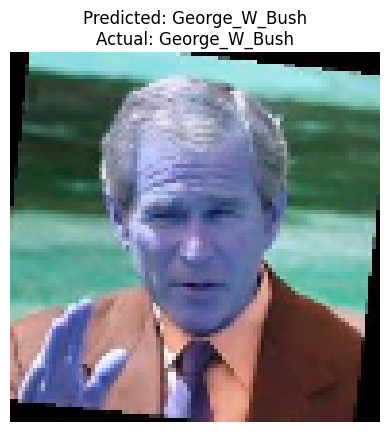

In [8]:
import matplotlib.pyplot as plt
import numpy as np

index = 10  # choose any test image

test_image = X_test[index]
true_label = y_test[index]

prediction = model.predict(np.expand_dims(test_image, axis=0))
predicted_class = np.argmax(prediction)

plt.imshow(test_image)
plt.title(f"Predicted: {label_map[predicted_class]}\nActual: {label_map[true_label]}")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


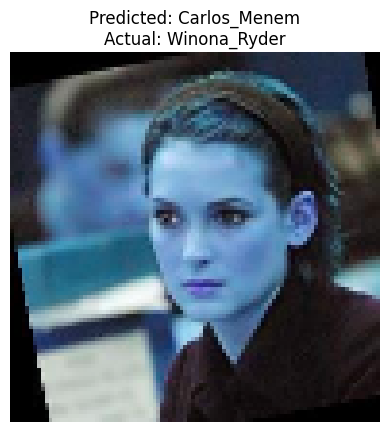

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


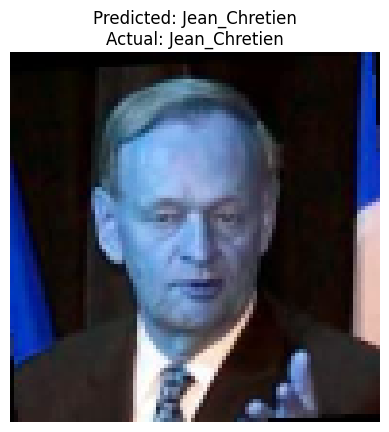

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


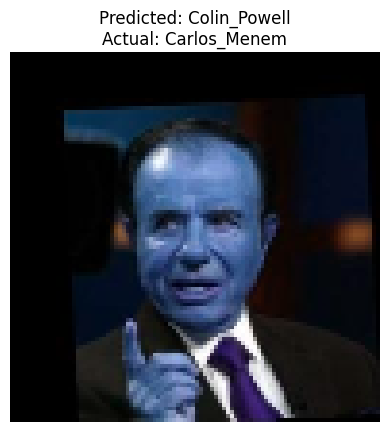

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


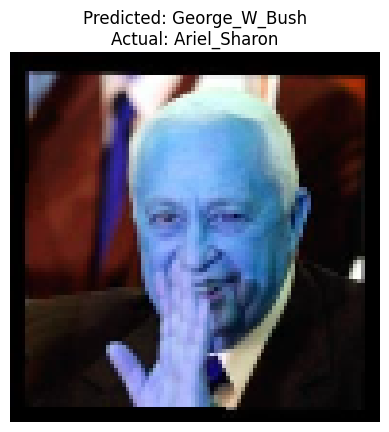

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


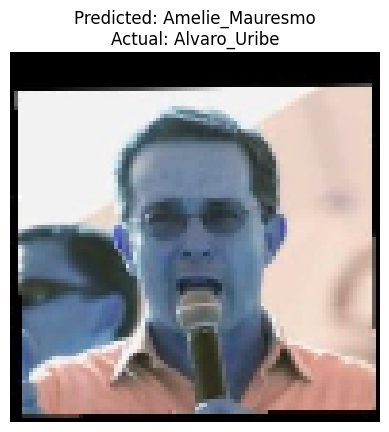

In [9]:
for i in range(5):

    img = X_test[i]
    true_label = y_test[i]

    prediction = model.predict(np.expand_dims(img, axis=0))
    predicted_class = np.argmax(prediction)

    plt.imshow(img)
    plt.title(f"Predicted: {label_map[predicted_class]}\nActual: {label_map[true_label]}")
    plt.axis("off")
    plt.show()

In [10]:
top3 = np.argsort(prediction[0])[-3:][::-1]

for i in top3:
    print(label_map[i], prediction[0][i])

Amelie_Mauresmo 0.97928107
Hugo_Chavez 0.013111027
George_W_Bush 0.0067771897


In [11]:
import cv2
import numpy as np

IMAGE_SIZE = 96

def predict_image(image_path, true_label=None):

    img = cv2.imread(image_path)

    img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
    img = img / 255.0

    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)[0]

    top3_idx = np.argsort(prediction)[-3:][::-1]

    print("\nTop 3 Predictions:")

    for i in top3_idx:
        print(f"{label_map[i]} : {prediction[i]:.3f}")

    predicted_class = top3_idx[0]
    predicted_name = label_map[predicted_class]

    print("\nFinal Prediction:", predicted_name)

    if true_label is not None:
        if predicted_name == true_label:
            print("✅ Correct Prediction")
        else:
            print("❌ Wrong Prediction")
            print("Actual:", true_label)

In [14]:
predict_image("archive/lfw-deepfunneled/lfw-deepfunneled/Atal_Bihari_Vajpayee/Atal_Bihari_Vajpayee_0006.jpg", true_label="George_W_Bush")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Top 3 Predictions:
Atal_Bihari_Vajpayee : 1.000
David_Beckham : 0.000
Juan_Carlos_Ferrero : 0.000

Final Prediction: Atal_Bihari_Vajpayee
❌ Wrong Prediction
Actual: George_W_Bush
